## Benchmark notebook, after discussing with Mauritius Seeger

Note that connecting to the GPU backend of colab produce notable speedup (optional). If GPU is unavailable, just remove sn_gpu version

# Results:

/!\ the exact number vary a lots from a session to an other because of google colab. This gives order of magnitudes, showing sensibly equivalent performance between squarenet and kdtree

| Method     |  Build Time  of the structure (1 million  points, 2D) |
| ------------- | -----------: |
| SquareNet CPU | **0.66 s** |
| SquareNet GPU | **0.058 s** |
| Scipy KDTree  | **0.53 s** |

| Method     |  Query Time  of the structure (1 million  points, 2D) |
| ------------- | -----------: |
| SquareNet | **0.040 ms**/query|
| Scipy KDTree  | **0.043 ms**/query|

In [ ]:
!pip install SquareNet

In [96]:
from squarenet import SquareNet
from squarenet.sampler import samplepoints
from squarenet.backends import to_backend
from scipy.spatial import KDTree
import time

the first build time is slow, because pytorch is imported under the hood for GPU

In [97]:
sn_dummy = SquareNet(gridshape = (1000, 1000, 1), cuda = True)

any latter build will be instantaneous

In [98]:
sn_cpu = SquareNet(gridshape = (1000, 1000), backend = "numpy", cuda = False, verbose = 0)
sn_gpu = SquareNet(gridshape = (1000, 1000), backend = "torch", cuda = True, verbose = 0)

again this is slow, because it will download all the demo datasets from gtihub

In [99]:
pts_cpu = samplepoints("germany", plot_points = False)
print(pts_cpu.shape)
N = len(pts_cpu)

pts_gpu = to_backend(pts_cpu, "torch")

(1000000, 2)


# ⏱️ Let benchmark the fit ! (average on 10 samples)

In [100]:
cpu_times = []
gpu_times = []
scipy_times = []

for i in range(10):
    print(f"run {i}")

    pts_cpu = samplepoints("germany", plot_points=False)
    pts_gpu = to_backend(pts_cpu, "torch")

    start = time.time()
    sn_cpu.fit(pts_cpu)
    cpu_times.append(time.time() - start)

    start = time.time()
    sn_gpu.fit(pts_gpu)
    gpu_times.append(time.time() - start)

    start = time.time()
    KDTree_scipy = KDTree(pts_cpu)
    scipy_times.append(time.time() - start)


print("\n=== Average time over 10 runs ===")
print(f"SquareNet CPU : {sum(cpu_times) / len(cpu_times):.4f} s")
print(f"SquareNet GPU : {sum(gpu_times) / len(gpu_times):.4f} s")
print(f"Scipy KDTree  : {sum(scipy_times) / len(scipy_times):.4f} s")

run 0
run 1
run 2
run 3
run 4
run 5
run 6
run 7
run 8
run 9

=== Average time over 10 runs ===
SquareNet CPU : 0.9268 s
SquareNet GPU : 0.0552 s
Scipy KDTree  : 0.5992 s


In [101]:
#don't need the gpu version anymore
sn = sn_cpu
pts = pts_cpu

# 🎯 Neighbor search benchmark

Note that squarenet is pure python code, scipy is higly optimised C library


In [102]:
import random
import numpy as np
import time

squarenet_times = []
scipy_times = []

I = 1000 #average on 1000 query
for i in range(I):

    idx = random.randint(0, N - 1)

    grid_true = np.asarray(sn.mapidx(idx), dtype=int)
    target = pts[idx]

    if i <= 5:
        print(f"\n--- Run {i + 1}/10 ---")
        print("true index:", grid_true)

    # SquareNet
    start = time.time()
    grid_gess_sn = sn.search_sorted(target, n_iter = 3)
    sn_time = time.time() - start
    squarenet_times.append(sn_time)

    if i <= 5:
        print("found:", np.asarray(grid_gess_sn, dtype=int),
          "- SquareNet search sorted")

    # Scipy KDTree
    start = time.time()
    grid_gess_scipy = KDTree_scipy.query(target)[1]
    scipy_time = time.time() - start
    scipy_times.append(scipy_time)

    if i <= 5:
        print("found:", np.asarray(sn.mapidx(grid_gess_scipy), dtype=int),
          "- Scipy KDTree")


print(f"\n=== Average search time over {I} runs ===")
print(f"SquareNet search sorted : {1000*np.mean(squarenet_times):.6f} ms")
print(f"Scipy KDTree            : {1000*np.mean(scipy_times):.6f} ms")


--- Run 1/10 ---
true index: [714 964]
found: [715 962] - SquareNet search sorted
found: [714 964] - Scipy KDTree

--- Run 2/10 ---
true index: [147 814]
found: [146 810] - SquareNet search sorted
found: [147 814] - Scipy KDTree

--- Run 3/10 ---
true index: [890 689]
found: [889 691] - SquareNet search sorted
found: [890 689] - Scipy KDTree

--- Run 4/10 ---
true index: [161  30]
found: [160  29] - SquareNet search sorted
found: [161  30] - Scipy KDTree

--- Run 5/10 ---
true index: [272 900]
found: [272 899] - SquareNet search sorted
found: [272 900] - Scipy KDTree

--- Run 6/10 ---
true index: [  8 413]
found: [  7 409] - SquareNet search sorted
found: [  8 413] - Scipy KDTree

=== Average search time over 1000 runs ===
SquareNet search sorted : 0.038137 ms
Scipy KDTree            : 0.041809 ms


# 🗺️ squarenet vizualisatoin of the grid

figure will be saved at sqrnet/plot_5.png


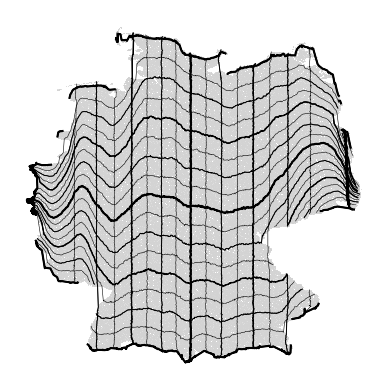

(<Figure size 400x400 with 1 Axes>, None)

In [103]:
sn.plot(style = "mesh")

# 🔎 Local zoom

Note some local inconsistencies, while the global structure is very good, that need to be postprocessed at the end if the goal is to produce a high quality mesh

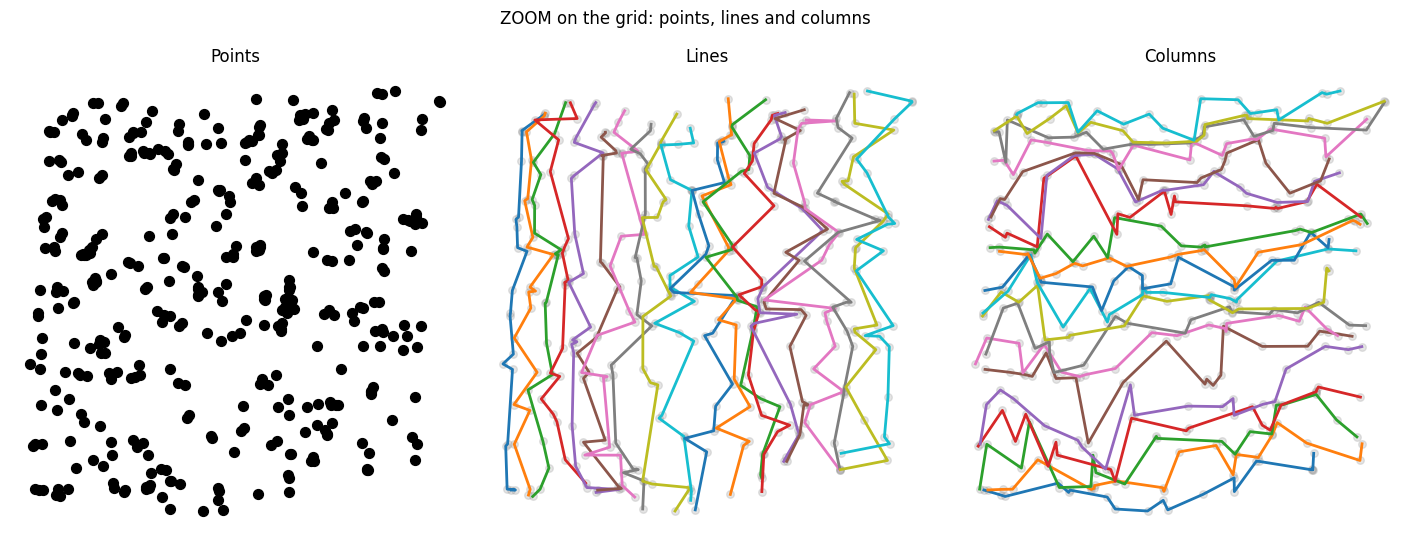

In [104]:
import matplotlib.pyplot as plt

x0, y0 = 500, 500  # local zoom
points = sn.pointsmaped[x0-10:x0+10, y0-10:y0+10]


# Plotting utilities
def scatter(x, ax, **kwargs):
    ax.scatter(x[..., 0], x[..., 1], **kwargs)
def plot(x, ax, **kwargs):
    ax.plot(x[..., 0], x[..., 1], **kwargs)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
# 1. Points
scatter(points, ax1, s=50, color="black")
ax1.set_title("Points")
ax1.axis("off")
# 2. Lines
scatter(points, ax2, s=30, color="grey", alpha=0.2)
for line in points:
    plot(line, ax2, linewidth=2)
ax2.set_title("Lines")
ax2.axis("off")
# 3. Columns
scatter(points, ax3, s=30, color="grey", alpha=0.2)
for column in points.transpose(1, 0, 2):
    plot(column, ax3, linewidth=2)
ax3.set_title("Columns")
ax3.axis("off")

#Show
plt.subplots_adjust(wspace=0.05)
fig.suptitle("ZOOM on the grid: points, lines and columns")
plt.show()

